In [1]:
import numpy as np
import torch
import random
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from torch import nn
from torch.utils.data import Dataset, DataLoader
from config import config
from tqdm.auto import tqdm
from utils import (
    build_metadata, split_metadata,
    print_split_summary, preprocess_img,
    sample_pixels, count_by_class, plot_class_distribution
)

/home/mohamed-ashraf/Desktop/projects/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("DEVICE:", config.DEVICE)

DEVICE: cuda


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config.RANDOM_STATE)

In [4]:
meta = build_metadata(config.DATA_DIR)
train_meta, val_meta, test_meta = split_metadata(meta)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks: 100%|██████████| 320/320 [00:00<00:00, 595.58it/s]

[train] images: 288
  Unknown  pixels=    9,930 images=102
  Greenery pixels=12,906,143 images=274
  Sand     pixels=4,699,743 images=239
  Water    pixels=  399,614 images= 46
  Cement   pixels=  858,938 images=225
  strata: {'cement_only': 185, 'base': 57, 'water_and_cement': 40, 'water_only': 6}
[val] images: 16
  Unknown  pixels=       70 images=  4
  Greenery pixels=  426,100 images= 14
  Sand     pixels=  482,084 images= 14
  Water    pixels=   66,644 images=  3
  Cement   pixels=   73,678 images= 13
  strata: {'cement_only': 11, 'base': 3, 'water_and_cement': 2}
[test] images: 16
  Unknown  pixels=      142 images=  5
  Greenery pixels=  787,344 images= 15
  Sand     pixels=  256,642 images= 14
  Water    pixels=      710 images=  2
  Cement   pixels=    3,738 images= 12
  strata: {'cement_only': 10, 'base': 4, 'water_and_cement': 2}


In [5]:
class LandCoverSegDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].astype(np.float32)
        mask = self.y[idx].astype(np.int64)
        return torch.from_numpy(img), torch.from_numpy(mask)

In [6]:
def process_pair(img_path, mask_path):
    img, mask, confidence, pixel_valid = preprocess_img(img_path, mask_path)

    valid = pixel_valid & (mask != 0) & (confidence * 100.0 >= config.MIN_CONFIDENCE)
    img = img.astype(np.float32)
    mask = mask.astype(np.uint8).copy()
    confidence = confidence.astype(np.float32)
    mask[~valid] = 0

    return img, mask, confidence


def build_dataset(split_df, n_jobs=-1):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'])
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    weight_parts = []

    for X, y, pixel_weight in results:
        X_parts.append(X)
        y_parts.append(y)
        weight_parts.append(pixel_weight)

    X_all = np.stack(X_parts, axis=0)
    y_all = np.stack(y_parts, axis=0)
    weight_all = np.stack(weight_parts, axis=0)
    return X_all, y_all, weight_all

Building dataset: 100%|██████████| 16/16 [00:00<00:00, 29826.16it/s]


Train full: (288, 12, 256, 256) {'Greenery': 12910611, 'Sand': 4666972, 'Water': 340378, 'Cement': 860302}
Val full  : (16, 12, 256, 256) {'Greenery': 426137, 'Sand': 482090, 'Water': 66669, 'Cement': 73680}
Test full : (16, 12, 256, 256) {'Greenery': 787482, 'Sand': 256642, 'Water': 710, 'Cement': 3742}
Greenery available=12,910,611 sampled=  800,000
Sand     available=4,666,972 sampled=  800,000
Water    available=  340,378 sampled=  340,378
Cement   available=  860,302 sampled=  800,000
Greenery available=  426,137 sampled=  426,137
Sand     available=  482,090 sampled=  482,090
Water    available=   66,669 sampled=   66,669
Cement   available=   73,680 sampled=   73,680
Greenery available=  787,482 sampled=  787,482
Sand     available=  256,642 sampled=  256,642
Water    available=      710 sampled=      710
Cement   available=    3,742 sampled=    3,742
Train sampled: (288, 12, 256, 256) {'Greenery': 800000, 'Sand': 800000, 'Water': 340378, 'Cement': 800000}
Val sampled  : (16, 12

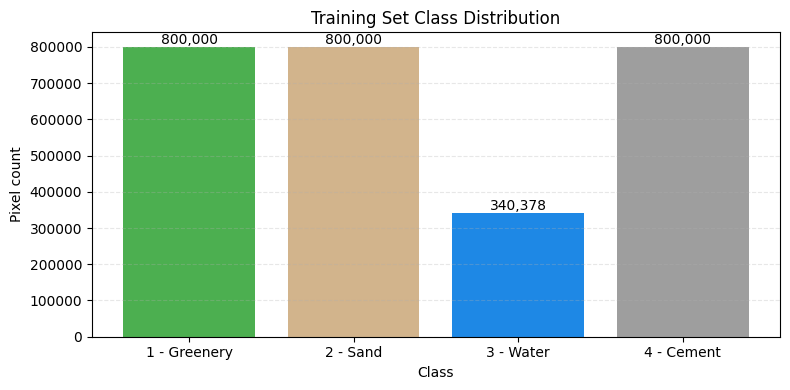

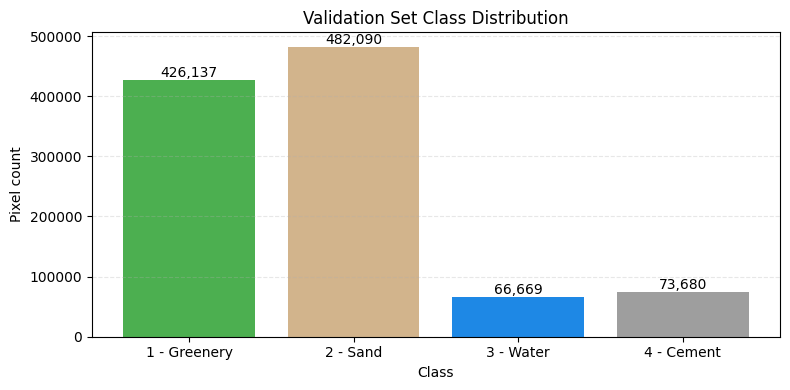

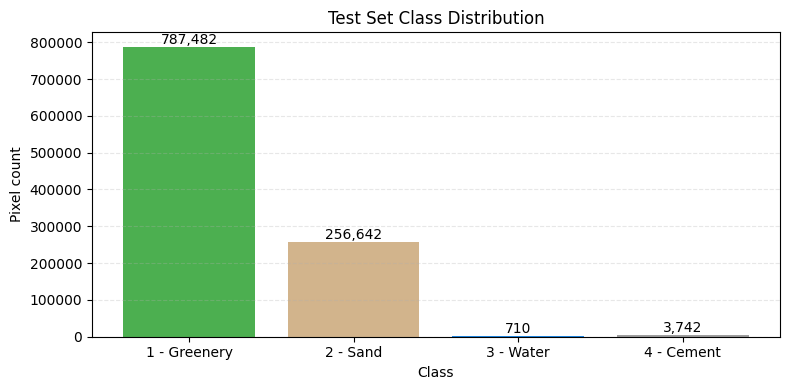

In [7]:
def apply_pixel_caps(masks, confidence, caps):
    flat_y = masks.reshape(-1)
    flat_conf = confidence.reshape(-1) if confidence is not None else None
    valid = flat_y != 0
    flat_idx = np.arange(flat_y.size, dtype=np.int64)

    sampled_idx, sampled_y, sampled_conf = sample_pixels(
        flat_idx[valid],
        flat_y[valid],
        caps,
        flat_conf[valid] if flat_conf is not None else None,
    )

    capped_y = np.zeros_like(flat_y)
    capped_y[sampled_idx] = sampled_y

    capped_conf = None
    if flat_conf is not None:
        capped_conf = np.zeros_like(flat_conf)
        capped_conf[sampled_idx] = sampled_conf

    return capped_y.reshape(masks.shape), None if capped_conf is None else capped_conf.reshape(confidence.shape)


X_train, y_train, conf_train = build_dataset(train_meta)
X_val, y_val, conf_val = build_dataset(val_meta)
X_test, y_test, conf_test = build_dataset(test_meta)

print('Train full:', X_train.shape, count_by_class(y_train[y_train != 0]))
print('Val full  :', X_val.shape, count_by_class(y_val[y_val != 0]))
print('Test full :', X_test.shape, count_by_class(y_test[y_test != 0]))

y_train, conf_train = apply_pixel_caps(y_train, conf_train, config.TRAIN_CAPS_DEEP)
y_val, conf_val = apply_pixel_caps(y_val, conf_val, config.VAL_TEST_CAPS)
y_test, conf_test = apply_pixel_caps(y_test, conf_test, config.VAL_TEST_CAPS)

train_valid = y_train != 0
val_valid = y_val != 0
test_valid = y_test != 0

print('Train sampled:', X_train.shape, count_by_class(y_train[train_valid]))
print('Val sampled  :', X_val.shape, count_by_class(y_val[val_valid]))
print('Test sampled :', X_test.shape, count_by_class(y_test[test_valid]))
print('Ignored train pixels:', int((~train_valid).sum()))
print('Train confidence weight range:', float(conf_train[train_valid].min()), float(conf_train[train_valid].max()))
plot_class_distribution(y_train[train_valid], 'Training Set Class Distribution')
plot_class_distribution(y_val[val_valid], 'Validation Set Class Distribution')
plot_class_distribution(y_test[test_valid], 'Test Set Class Distribution')

In [8]:
train_ds = LandCoverSegDataset(X_train, y_train)
val_ds   = LandCoverSegDataset(X_val, y_val)
test_ds  = LandCoverSegDataset(X_test, y_test)


train_loader = DataLoader(
    train_ds,
    batch_size=config.BATCH_SIZE,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Train images with cement:', int(train_meta['has_cement'].sum()))
print('Train images with water :', int(train_meta['has_water'].sum()))

Dataset sizes: 288 16 16
Train images with cement: 225
Train images with water : 46


In [9]:
class UNet(nn.Module):
    def __init__(self, encoder_name="resnet34", num_classes=5):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(12, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 12, kernel_size=1, bias=False),
            nn.BatchNorm2d(12),
            nn.ReLU(inplace=True),
        )

        self.unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=12,
            classes=num_classes,
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.unet(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")

24.478381 M parameters


In [10]:
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    out = model(images)

print("Input shape :", images.shape)
print("Mask shape  :", masks.shape)
print("Output shape:", out.shape)

Input shape : torch.Size([8, 12, 256, 256])
Mask shape  : torch.Size([8, 256, 256])
Output shape: torch.Size([8, 5, 256, 256])


In [11]:
def compute_batch_iou(preds, targets, num_classes=5, ignore_index=0):
    preds = preds.view(-1)
    targets = targets.view(-1)

    valid = targets != ignore_index
    preds = preds[valid]
    targets = targets[valid]

    ious = []

    for cls in range(num_classes):
        if cls == ignore_index:
            continue

        pred_c = preds == cls
        target_c = targets == cls

        intersection = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()

        if union > 0:
            ious.append(intersection / union)

    return float(np.mean(ious)) if len(ious) > 0 else 0.0


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for images, masks in tqdm(loader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_iou = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        preds = torch.argmax(logits, dim=1)
        iou = compute_batch_iou(preds, masks, num_classes=5, ignore_index=0)

        total_loss += loss.item()
        total_iou += iou

    return total_loss / len(loader), total_iou / len(loader)

In [ ]:
num_epochs = 25
best_val_iou = -1.0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_iou = validate(model, val_loader, criterion, device)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_mIoU={val_iou:.4f}"
    )

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), "best_unet.pth")
        print("Saved best model")

Training: 100%|██████████| 36/36 [00:05<00:00,  6.08it/s]


Epoch 1/25 | train_loss=1.2917 | val_loss=8.4707 | val_mIoU=0.2079
Saved best model


Training: 100%|██████████| 36/36 [00:05<00:00,  6.92it/s]


Epoch 2/25 | train_loss=0.8656 | val_loss=0.9900 | val_mIoU=0.3112
Saved best model


Training: 100%|██████████| 36/36 [00:05<00:00,  6.99it/s]


...

Epoch 23/25 | train_loss=0.5388 | val_loss=0.5046 | val_mIoU=0.6073


Training: 100%|██████████| 36/36 [00:05<00:00,  6.92it/s]


Epoch 24/25 | train_loss=0.5316 | val_loss=0.3651 | val_mIoU=0.6319


Training: 100%|██████████| 36/36 [00:05<00:00,  7.14it/s]


Epoch 25/25 | train_loss=0.5082 | val_loss=0.4024 | val_mIoU=0.6264


In [21]:
checkpoint = torch.load("best_unet.pth", map_location=config.DEVICE)
model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(device)
model.load_state_dict(checkpoint)
model.eval()

UNet(
  (stem): Sequential(
    (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(32, 12, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (7): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (unet): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(12, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1):

In [22]:
@torch.no_grad()
def show_prediction(model, dataset, idx=0):
    if isinstance(model, dict):
        loaded_model = UNet(
            encoder_name="resnet34",
            num_classes=5
        ).to(device)
        loaded_model.load_state_dict(model)
        model = loaded_model

    model.eval()

    image, mask = dataset[idx]
    x = image.unsqueeze(0).to(device)

    logits = model(x)
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    image_np = image.numpy()
    mask_np = mask.numpy()

    rgb = image_np[[3, 2, 1]]
    if config.BAND_MEANS is not None and config.BAND_STDS is not None:
        rgb = rgb * config.BAND_STDS[[3, 2, 1], None, None] + config.BAND_MEANS[[3, 2, 1], None, None]
    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = np.clip(rgb * 3.0, 0, 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="tab10", vmin=0, vmax=4)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred, cmap="tab10", vmin=0, vmax=4)
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

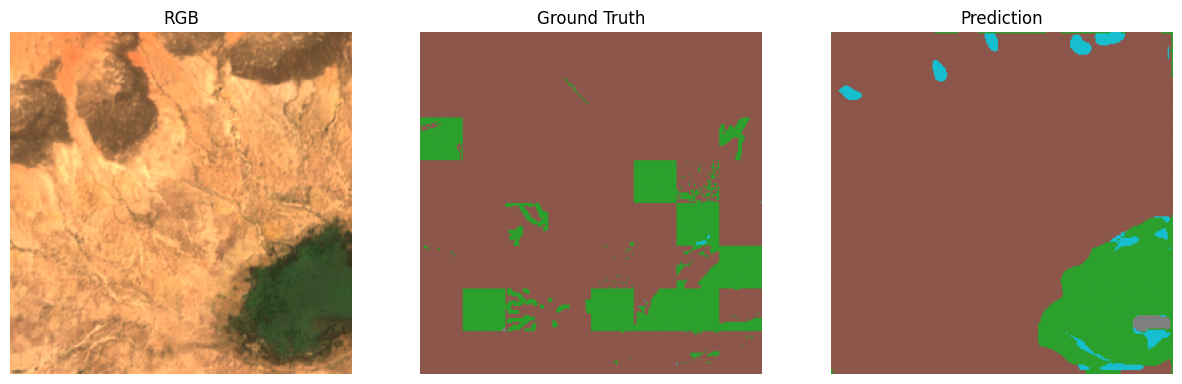

In [27]:
show_prediction(model, val_ds, idx=5)